In [ ]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from ddpm_lib.data_loaders import get_nifty_regime_data,prepare_dataloaders,compute_regime_score
from ddpm_lib.models import f_net,FiLMLayer
from ddpm_lib.noisify_time_emb import cosine_beta_scheduler,noisify
from ddpm_lib.diffusion_utils import FiLMTabularDDPM
from ddpm_lib.samplers import sample_n_samples


ImportError: cannot import name 'sample_with_conditions' from 'ddpm_lib.samplers' (..\ddpm_lib\samplers.py)

In [ ]:
risk_df = get_nifty_regime_data()
risk_df = get_nifty_regime_data()
risk_df['regime_score'] = compute_regime_score(risk_df)
risk_df['regime_score'] = risk_df['regime_score'].fillna(0.5)
risk_df['regime'] = (risk_df['regime_score'] > 0.5).astype(int)

train_dl, val_dl, condition_df, scaler_x, scaler_cond,val_df = prepare_dataloaders(
    risk_df,
    batch_size=64,
    train_size=0.80,
    val_size=0.10
)

print(f"\nDataLoader batch info:")
print(f"  Train batches: {len(train_dl)}")
print(f"  Validation batches: {len(val_dl)}")
print(f"\nConditioning dataframe shape: {condition_df.shape}")
print(f"Conditioning date range: {condition_df.index[0]} to {condition_df.index[-1]}")

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Data split:
  Train: 2037 samples (80.0%)
  Validation: 255 samples (10.0%)
  Conditioning: 255 samples (10.0%)

DataLoader batch info:
  Train batches: 32
  Validation batches: 4

Conditioning dataframe shape: (255, 12)
Conditioning date range: 2025-02-14 00:00:00 to 2026-02-26 00:00:00


In [ ]:
T = 200
betas = cosine_beta_scheduler(T)
alphas = 1-betas
alphas_bar = torch.cumprod(torch.from_numpy(alphas).float(),dim=0)
diffusion_model = FiLMTabularDDPM(d_in=1,model=f_net,cond_in_classes=2,continious_conditioning_in=8)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=3e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
diffusion_model.to(device)
alphas_bar = alphas_bar.to(device)
print(f"Training on device: {device}")

Training on device: cpu


In [ ]:
from tqdm.auto import tqdm

num_epochs = 200
diffusion_model.train()
drop_prob_cat  = 0.15
drop_prob_cont = 0.10
null_label     = 0

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    progress_bar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in progress_bar:
        x0, c, cond = batch

        x0   = x0.to(device)
        c    = c.to(device)
        cond = cond.to(device)

        if x0.dim() == 1:
            x0 = x0.unsqueeze(1)

        B = c.shape[0]


        drop_cat  = torch.rand(B, device=device) < drop_prob_cat
        drop_cont = torch.rand(B, device=device) < drop_prob_cont

        c    = c.clone()
        cond = cond.clone()

        c[drop_cat]    = null_label  
        cond[drop_cont] = 0.0        

        xt, t, eps = noisify(T, x0, alphas_bar)

        eps_pred = diffusion_model(xt, c, cond, t.float())

        loss = F.smooth_l1_loss(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / num_batches
    diffusion_model.eval()
    val_loss, val_batches = 0.0, 0
    with torch.no_grad():
        for batch in val_dl:
            x0v, cv, condv = batch
            x0v, cv, condv = x0v.to(device), cv.to(device), condv.to(device)
            if x0v.dim() == 1:
                x0v = x0v.unsqueeze(1)
            xtv, tv, epsv = noisify(T, x0v, alphas_bar)
            eps_predv = diffusion_model(xtv, cv, condv, tv.float())
            val_loss += F.smooth_l1_loss(eps_predv, epsv).item()
            val_batches += 1
    avg_val_loss = val_loss / val_batches
    diffusion_model.train()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_loss:.6f} | Val: {avg_val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("\nTraining completed!")

Epoch 1/200: 100%|██████████| 32/32 [00:07<00:00,  4.13it/s, loss=0.428]



Epoch 1/200 | Train: 0.429593 | Val: 0.433666 | LR: 3.00e-04


Epoch 2/200: 100%|██████████| 32/32 [00:03<00:00,  9.73it/s, loss=0.311]



Epoch 2/200 | Train: 0.354855 | Val: 0.231807 | LR: 3.00e-04


Epoch 3/200: 100%|██████████| 32/32 [00:08<00:00,  3.98it/s, loss=0.238]



...

Epoch 198/200 | Train: 0.193914 | Val: 0.192448 | LR: 7.40e-08


Epoch 199/200: 100%|██████████| 32/32 [00:03<00:00,  9.90it/s, loss=0.271]



Epoch 199/200 | Train: 0.196646 | Val: 0.265662 | LR: 1.85e-08


Epoch 200/200: 100%|██████████| 32/32 [00:04<00:00,  7.44it/s, loss=0.144]



Epoch 200/200 | Train: 0.197434 | Val: 0.229724 | LR: 0.00e+00

Training completed!


In [ ]:
#| default_exp abalation_test

c:\Users\GARVIT\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



[Real Continuous Conditioning]  regime=0, n_samples=1000



[Zeroed Continuous (ablation)]  regime=0, n_samples=1000



─── Distribution Statistics ───

  Generated (Real Continuous):
    mean=-0.001306  std=0.012212  skew=-2.429  kurt=39.757

  Generated (Zero Continuous):
    mean=-0.001484  std=0.012217  skew=-2.718  kurt=29.732

  Actual Val Regime 0:
    mean=0.000102  std=0.007070  skew=0.255  kurt=4.445

─── KS Tests (higher statistic = more different) ───
  Real vs Zero conditioning : stat=0.0330,   p=0.6478
  Real vs Actual            : stat=0.0981,   p=0.0398
  Zero vs Actual            : stat=0.1121,   p=0.0121

  [Warning] Real and Zero distributions are NOT significantly different (p > 0.05).
     → Continuous conditioning may not be having a meaningful effect on the model.


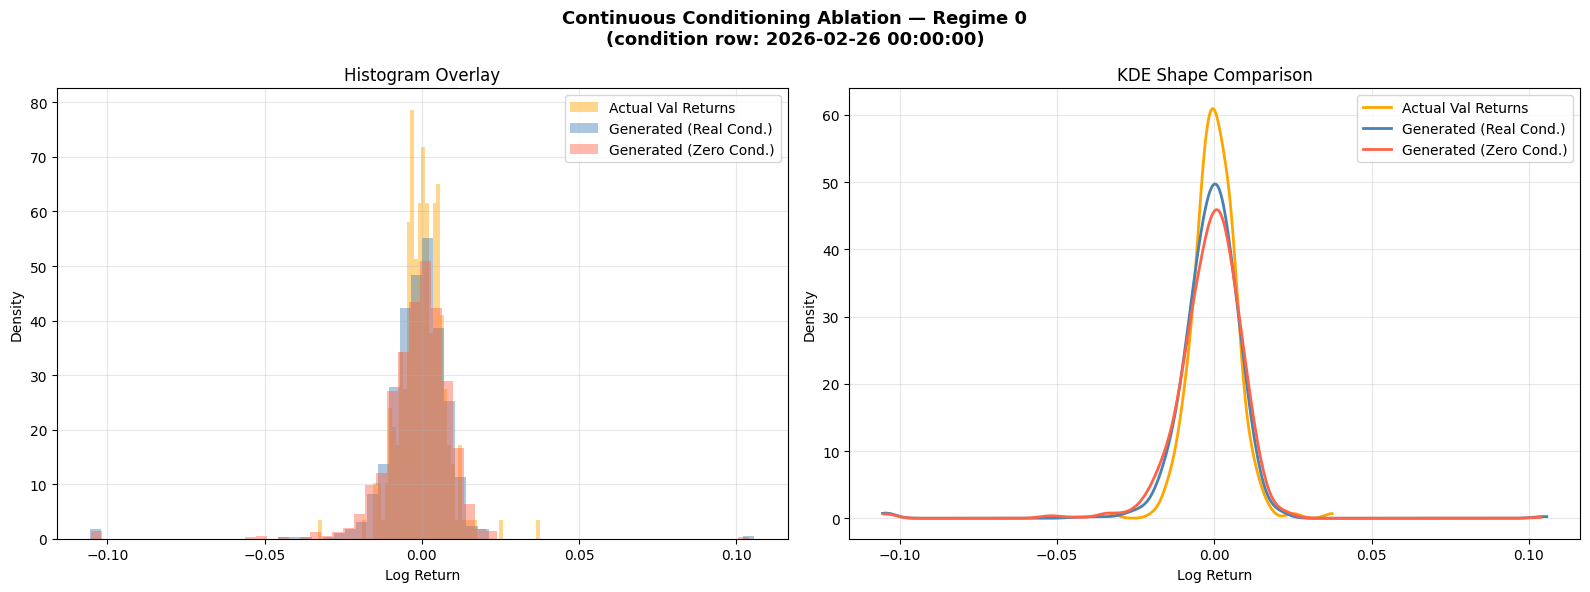

In [ ]:
#| export
from scipy import stats
import matplotlib.pyplot as plt
def sample_with_ablation(
    condition_row,
    n_samples,
    model,
    alphas,
    betas,
    alphas_bar,
    scaler_x,
    scaler_cond,
    guidance_scale_cat = 2.5,
    guidance_scale_cont = 1.5,
    zero_continuous=False,   
    seed=42,
):

    global T   

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    alphas_t   = torch.from_numpy(alphas).float().to(device)
    betas_t    = torch.from_numpy(betas).float().to(device)
    alphas_bar = alphas_bar.to(device)

    model.eval()
    model.to(device)

    torch.manual_seed(seed)
    xt = torch.randn((n_samples, 1), device=device)
    regime  = int(condition_row['regime'])
    c_cond  = torch.full((n_samples,), regime + 1, device=device, dtype=torch.long)
    cont_feature_names = ['realized_vol', 'VIX', 'RSI', 'skew', 'kurtosis', 'vol_spike', 'RSI_velocity', 'regime_score']

    if zero_continuous:
        continuous_cond = torch.zeros((n_samples, 8), device=device, dtype=torch.float32)
        label = "Zeroed Continuous (ablation)"
    else:
        raw_values = np.array([condition_row[f] for f in cont_feature_names]).reshape(1, -1)
        scaled_values = scaler_cond.transform(raw_values)
        continuous_cond = torch.tensor(scaled_values, dtype=torch.float32, device=device).repeat(n_samples, 1)
        label = "Real Continuous Conditioning"
    null_c = torch.full_like(c_cond,0)
    null_cond = torch.zeros_like(continuous_cond)

    print(f"\n[{label}]  regime={regime}, n_samples={n_samples}")

    
    with torch.no_grad():
        for t in tqdm(reversed(range(T)), desc=f"Sampling ({label[:4]}…)", total=T, leave=False):
            t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

            alpha_t      = alphas_t[t].unsqueeze(0).unsqueeze(1)
            beta_t       = betas_t[t].unsqueeze(0).unsqueeze(1)
            alpha_bar_t  = alphas_bar[t].unsqueeze(0).unsqueeze(1)

            sqrt_alpha_t             = torch.sqrt(alpha_t)
            sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar_t)

            t_float = t_tensor.float()
            eps_uncond = model(xt,null_c,null_cond,t_float)
            eps_cat = model(xt,c_cond,null_cond,t_float)
            eps_hat = model(xt, null_c, continuous_cond, t_tensor.float())
            eps_guided = (eps_uncond  + guidance_scale_cat * (eps_cat - eps_uncond) + guidance_scale_cont * (eps_hat - eps_uncond)).clamp(-3,3)
            mean_t = (xt - (beta_t / sqrt_one_minus_alpha_bar) * eps_guided) / sqrt_alpha_t

            if t > 0:
                torch.manual_seed(seed + t)   
                z  = torch.randn_like(xt)
                xt = mean_t + torch.sqrt(beta_t) * z
                xt = xt.clamp(-10.0,10.0)
            else:
                xt = mean_t

    return scaler_x.inverse_transform(xt.cpu().numpy())



def compare_conditioning_ablation(
    condition_row,
    val_df_orig,         
    n_samples,
    model,
    alphas,
    betas,
    alphas_bar,
    scaler_x,
    scaler_cond,
    guidance_scale_cat = 2.5,
    guidance_scale_cont = 1.5,
    regime_to_check=0,
):

    samples_real  = sample_with_ablation(
        condition_row, n_samples, model, alphas, betas, alphas_bar,
        scaler_x, scaler_cond, guidance_scale_cat = 2.5,guidance_scale_cont = 1.5,zero_continuous=False
    ).flatten()

    samples_zero  = sample_with_ablation(
        condition_row, n_samples, model, alphas, betas, alphas_bar,
        scaler_x, scaler_cond, guidance_scale_cat = 2.5,guidance_scale_cont = 1.5,zero_continuous=True
    ).flatten()

    actual_returns = val_df_orig[val_df_orig['regime'] == regime_to_check]['target_return'].dropna().values

    def describe(arr, name):
        print(f"\n  {name}:")
        print(f"    mean={arr.mean():.6f}  std={arr.std():.6f}  "
              f"skew={stats.skew(arr):.3f}  kurt={stats.kurtosis(arr):.3f}")

    print("\n─── Distribution Statistics ───")
    describe(samples_real,  "Generated (Real Continuous)")
    describe(samples_zero,  "Generated (Zero Continuous)")
    describe(actual_returns, f"Actual Val Regime {regime_to_check}")

    ks_real_vs_zero = stats.ks_2samp(samples_real, samples_zero)
    ks_real_vs_actual = stats.ks_2samp(samples_real, actual_returns)
    ks_zero_vs_actual = stats.ks_2samp(samples_zero, actual_returns)

    print("\n─── KS Tests (higher statistic = more different) ───")
    print(f"  Real vs Zero conditioning : stat={ks_real_vs_zero.statistic:.4f},   p={ks_real_vs_zero.pvalue:.4f}")
    print(f"  Real vs Actual            : stat={ks_real_vs_actual.statistic:.4f},   p={ks_real_vs_actual.pvalue:.4f}")
    print(f"  Zero vs Actual            : stat={ks_zero_vs_actual.statistic:.4f},   p={ks_zero_vs_actual.pvalue:.4f}")

    if ks_real_vs_zero.pvalue > 0.05:
        print("\n  [Warning] Real and Zero distributions are NOT significantly different (p > 0.05).")
        print("     → Continuous conditioning may not be having a meaningful effect on the model.")
    else:
        print("\n  [Success] Real and Zero distributions ARE significantly different (p < 0.05).")
        print("     → Continuous conditioning is influencing the generated samples.")

    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"Continuous Conditioning Ablation — Regime {regime_to_check}\n"
        f"(condition row: {condition_row.name})",
        fontsize=13, fontweight='bold'
    )

    bins = 60

    ax = axes[0]
    ax.hist(actual_returns,  bins=bins, density=True, alpha=0.45, color='orange', label='Actual Val Returns')
    ax.hist(samples_real,    bins=bins, density=True, alpha=0.45, color='steelblue', label='Generated (Real Cond.)')
    ax.hist(samples_zero,    bins=bins, density=True, alpha=0.45, color='tomato',  label='Generated (Zero Cond.)')
    ax.set_title("Histogram Overlay")
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    from scipy.stats import gaussian_kde
    for arr, color, lbl in [
        (actual_returns, 'orange',    'Actual Val Returns'),
        (samples_real,   'steelblue', 'Generated (Real Cond.)'),
        (samples_zero,   'tomato',    'Generated (Zero Cond.)'),
    ]:
        arr_clean = arr[np.isfinite(arr)]
        if len(arr_clean) > 1:
            kde = gaussian_kde(arr_clean)
            xs  = np.linspace(arr_clean.min(), arr_clean.max(), 500)
            ax.plot(xs, kde(xs), color=color, lw=2, label=lbl)
    ax.set_title("KDE Shape Comparison")
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return samples_real, samples_zero




condition_row = condition_df[condition_df['regime'] == 0].iloc[-1]

samples_real, samples_zero = compare_conditioning_ablation(
    condition_row  = condition_row,
    val_df_orig    = condition_df,    
    n_samples      = 1000,
    model          = diffusion_model,
    alphas         = alphas,
    betas          = betas,
    alphas_bar     = alphas_bar,
    scaler_x       = scaler_x,
    scaler_cond    = scaler_cond,
    guidance_scale_cat = 1.5,
    guidance_scale_cont = 1.0,
    regime_to_check= 0,
)